In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib as mt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import pywt
from math import floor
import joblib

In [2]:
color_scale = 'coolwarm'
cmap = plt.colormaps[color_scale].copy()
cmap.set_bad("darkgrey")

Here I will analyze the results from `apParamSweep.py` and `apStabilitySweep.py` to find an optimal model for the AP clustering. Then I will manually sort the clusters from the optimal AP model to run through the SVM. 

An overview of the entire semisupervised pipeline and how AP works can be found in the `semisupervised.ipynb` notebook on the [github repo](https://github.com/cmhinkle/semi_supervised_pulses_BeEST).

# AP Param Search

Lets load the results of the AP param search:

In [3]:
ap_param_grid = pd.read_pickle(f'../data/20260819_ap_grid_day16_chan03_10000_20260803_2.pkl')

In [4]:
ap_param_grid.head()

,preference,damping,seed,n_clusters,converged,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size
0,-27.941062,0.85,23,173,True,67,68,0.393064,0.0068,1,708,57.803468,9.0
1,-26.312706,0.85,23,180,True,105,69,0.383333,0.0069,1,708,55.555556,8.0
2,-24.684350,0.85,23,193,True,63,78,0.404145,0.0078,1,677,51.813472,8.0
3,-23.055993,0.85,23,208,True,110,84,0.403846,0.0084,1,639,48.076923,8.0
4,-21.427637,0.85,23,234,True,119,103,0.440171,0.0103,1,636,42.735043,6.0


In [5]:
ap_param_grid.describe()

,preference,damping,seed,n_clusters,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size
count,144.000000,144.000000,144.0,144.000000,144.000000,144.000000,144.000000,144.000000,144.0,144.000000,144.000000,144.000000
mean,-18.985102,0.920000,23.0,413.236111,148.243056,264.083333,0.553020,0.026408,1.0,779.361111,37.491745,3.750000
std,5.640792,0.044089,0.0,308.688292,78.695149,265.194097,0.146232,0.026519,0.0,901.601928,24.987901,3.198011
min,-27.941062,0.850000,23.0,64.000000,16.000000,51.000000,0.381215,0.005100,1.0,441.000000,8.291874,1.000000
25%,-23.463082,0.885000,23.0,194.000000,107.000000,78.000000,0.405797,0.007800,1.0,522.000000,20.593305,1.000000
50%,-18.985102,0.920000,23.0,286.500000,132.000000,144.500000,0.532907,0.014450,1.0,625.000000,35.101691,1.000000
75%,-14.507122,0.955000,23.0,492.750000,172.000000,318.000000,0.686985,0.031800,1.0,640.000000,51.546392,7.250000
max,-10.029142,0.990000,23.0,1206.000000,474.000000,967.000000,0.803824,0.096700,1.0,6778.000000,156.250000,9.000000


In [6]:
ap_param_grid[ap_param_grid['converged'] == False]

,preference,damping,seed,n_clusters,converged,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size


We can see that there were 144 parameter combinations that we searched, all of whiched converged. The other parameters varied as expected. 

The goal is to find a parameter region where the clustering is stable and the clusters have a physically meaningful strucutre. 

## Cluster Size Analysis

In [7]:
df = ap_param_grid.sort_values(["preference", "damping"]).copy()

In [8]:
df["cluster_change_pref"] = (
    df
    .groupby("damping")["n_clusters"]
    .pct_change()
)

df["cluster_change_damping"] = (
    df
    .sort_values(["preference", "damping"])
    .groupby("preference")["n_clusters"]
    .pct_change()
)

In [9]:
df.head()

,preference,damping,seed,n_clusters,converged,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size,cluster_change_pref,cluster_change_damping
0,-27.941062,0.850000,23,173,True,67,68,0.393064,0.0068,1,708,57.803468,9.0,NaN,NaN
12,-27.941062,0.862727,23,173,True,69,68,0.393064,0.0068,1,708,57.803468,9.0,NaN,0.0
24,-27.941062,0.875455,23,173,True,71,68,0.393064,0.0068,1,708,57.803468,9.0,NaN,0.0
36,-27.941062,0.888182,23,173,True,77,68,0.393064,0.0068,1,708,57.803468,9.0,NaN,0.0
48,-27.941062,0.900909,23,173,True,86,68,0.393064,0.0068,1,709,57.803468,9.0,NaN,0.0


Lets make a few pivot tables to describe the various metrics for the parameter space.

In [10]:
pivot_n_clusters = df.pivot(
    index="preference",
    columns="damping",
    values="n_clusters"
)

In [11]:
pivot_frac_singleton_clusters = df.pivot(
        index="preference",
        columns="damping",
        values="fraction_singleton_clusters"
    )

In [12]:
pivot_frac_singleton_events = df.pivot(
    index="preference",
    columns="damping",
    values="fraction_singleton_events"
)

In [13]:
pivot_n_iter = df.pivot(
    index="preference",
    columns="damping",
    values="n_iter"
)

In [14]:
pivot_median_cluster_size = df.pivot(
    index="preference",
    columns="damping",
    values="median_cluster_size"
)

In [15]:
pivot_cluster_change_damp = df.pivot(
    index="preference",
    columns="damping",
    values="cluster_change_damping"
)

In [16]:
pivot_cluster_change_pref = df.pivot(
    index="preference",
    columns="damping",
    values="cluster_change_pref"
)

Here we see that relativly low change in `n_clusters` for for all values where `damping<0.99`

In [17]:
df_normal = df[df["damping"] < 0.99]

### Parameter Heatmaps

First lets look at the number of clusters, fraction of singleton events, and ____ for each parameter set. 

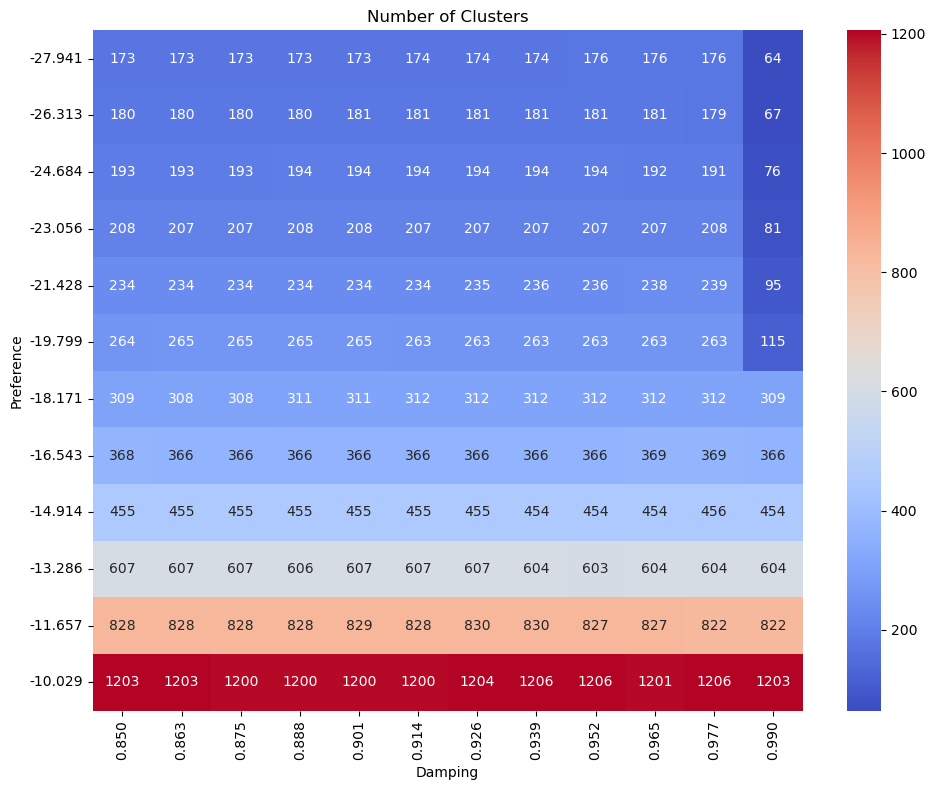

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_n_clusters,
    annot=True,
    fmt=".0f",
    cmap=cmap
)

plt.xticks(
    ticks=np.arange(len(pivot_n_clusters.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_n_clusters.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_n_clusters.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_n_clusters.index],
    rotation=0
)

plt.title('Number of Clusters')
plt.xlabel('Damping')
plt.ylabel('Preference')
plt.tight_layout()

plt.show()
plt.close()


A lower `pref` value results in fewer clusters. For `damp` values below `0.99` the number of clusters has remains consistatnt for a given `pref` values. 

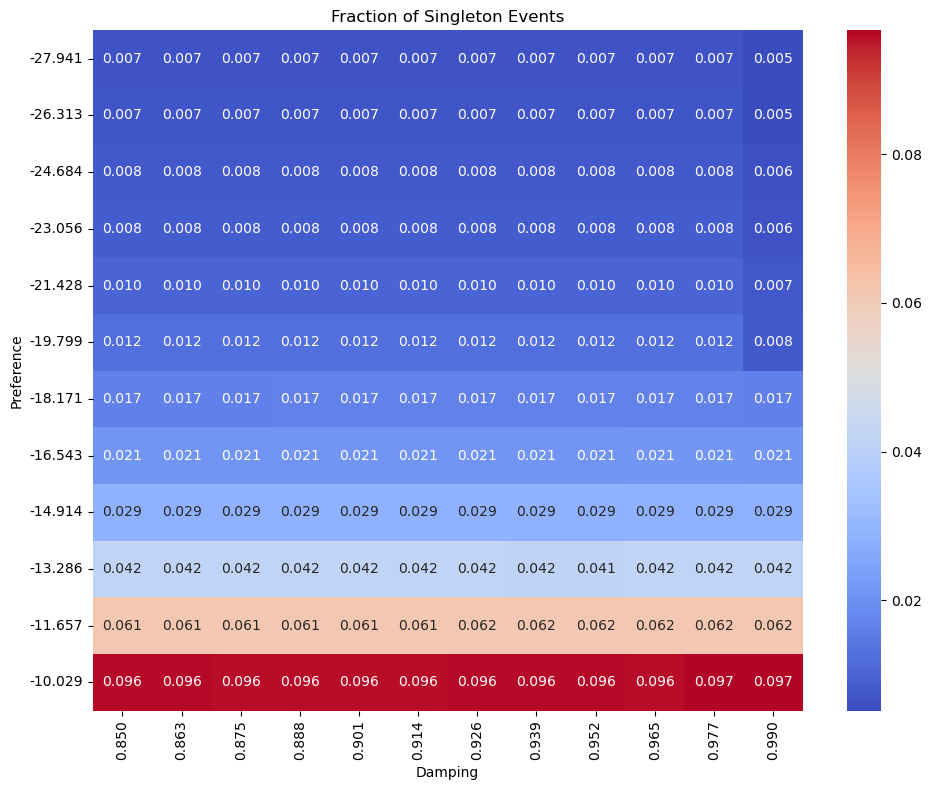

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_frac_singleton_events,
    annot=True,
    fmt="0.3f",
    cmap=cmap
)

plt.xticks(
    ticks=np.arange(len(pivot_frac_singleton_events.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_frac_singleton_events.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_frac_singleton_events.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_frac_singleton_events.index],
    rotation=0
)

plt.title('Fraction of Singleton Events')
plt.xlabel('Damping')
plt.ylabel('Preference')
plt.tight_layout()

plt.show()
plt.close()

Here we see that a lower `pref` value results in a lower fraction of singleton events. A higher d`damp` has a slight impact on a lower fraction of singleton events. A lower `pref` value has signifigantly higher impact on the fraction of singleton events. 

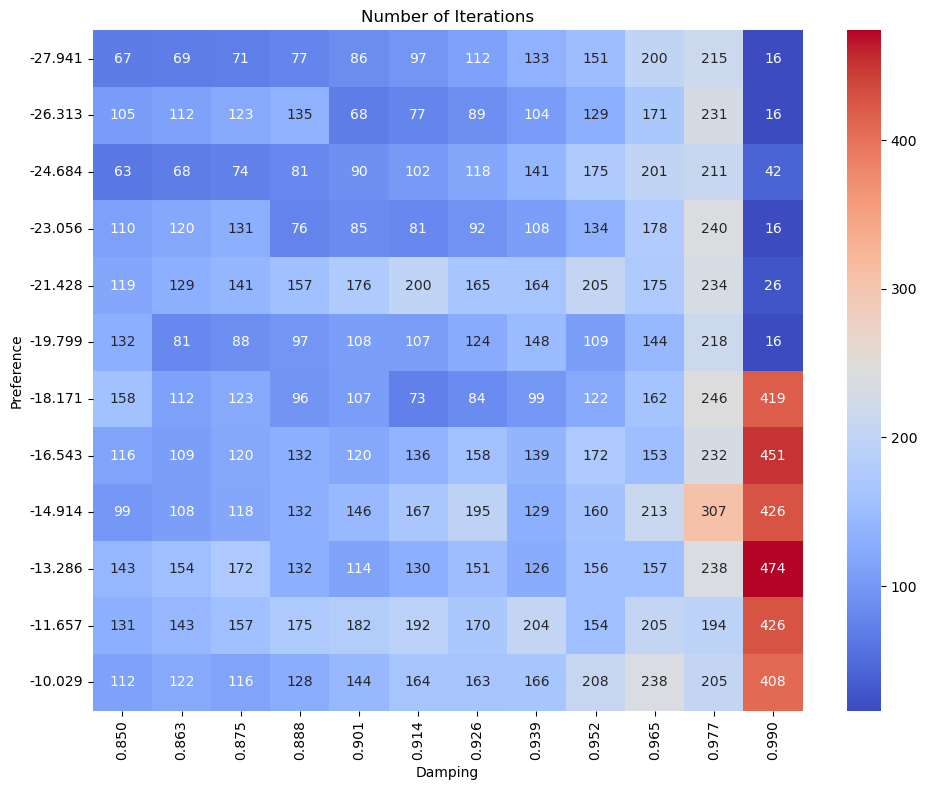

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_n_iter,
    annot=True,
    fmt=".0f",
    cmap=cmap
)

plt.xticks(
    ticks=np.arange(len(pivot_n_iter.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_n_iter.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_n_iter.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_n_iter.index],
    rotation=0
)

plt.title('Number of Iterations')
plt.xlabel('Damping')
plt.ylabel('Preference')
plt.tight_layout()

plt.show()
plt.close()

### Number of Clusters vs Preference

Now lets look at how the preference values affects the number of clusters. 

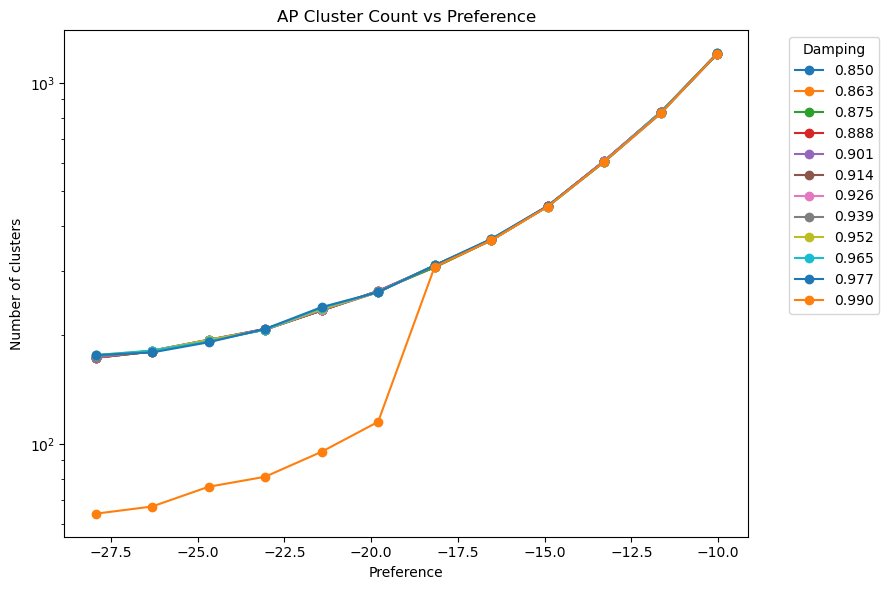

In [21]:
dampings = df['damping']

plt.figure(figsize=(9, 6))

for damping in sorted(dampings.unique()):
    subset = df[dampings == damping]

    plt.plot(
        subset["preference"],
        subset["n_clusters"],
        marker="o",
        label=f"{damping:.3f}"
    )

plt.xlabel("Preference")
plt.ylabel("Number of clusters")
plt.title("AP Cluster Count vs Preference")
plt.legend(title="Damping", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.semilogy()

plt.tight_layout()
plt.show()

Here we see that the damping value largely does not affect the number of clusters for `damping > 0.977`. Below a preference value of $\approx 18$ the behavior of the number of clusters for `damping = 0.990` returns to lower damping values. 

### Affect of Damping

In [22]:
damping_sensitivity = (
    df.groupby("preference")["n_clusters"]
    .agg(
        min_clusters="min",
        max_clusters="max",
        mean_clusters="mean",
        std_clusters="std"
    )
)

damping_sensitivity["range"] = (
    damping_sensitivity["max_clusters"]
    - damping_sensitivity["min_clusters"]
)

damping_sensitivity

,min_clusters,max_clusters,mean_clusters,std_clusters,range
preference,,,,,
-27.941062,64,176,164.916667,31.804683,112
-26.312706,67,181,171.000000,32.758066,114
-24.684350,76,194,183.500000,33.867388,118
-23.055993,81,208,196.833333,36.481211,127
-21.427637,95,239,223.583333,40.529357,144
-19.799280,115,265,251.416667,42.970303,150
-18.170924,308,312,310.666667,1.669694,4
-16.542568,366,369,366.666667,1.230915,3
-14.914211,454,456,454.750000,0.621582,2


Lets also exclude `damping=0.99` since its behavior starts to differ compared to other `damping` values.

In [23]:
damping_sensitivity_normal = (
    df_normal.groupby("preference")["n_clusters"]
    .agg(
        min_clusters="min",
        max_clusters="max",
        mean_clusters="mean",
        std_clusters="std"
    )
)

damping_sensitivity_normal["range"] = (
    damping_sensitivity_normal["max_clusters"]
    - damping_sensitivity_normal["min_clusters"]
)

damping_sensitivity_normal

,min_clusters,max_clusters,mean_clusters,std_clusters,range
preference,,,,,
-27.941062,173,176,174.090909,1.300350,3
-26.312706,179,181,180.454545,0.687552,2
-24.684350,191,194,193.272727,1.009050,3
-23.055993,207,208,207.363636,0.504525,1
-21.427637,234,239,235.272727,1.793929,5
-19.799280,263,265,263.818182,0.981650,2
-18.170924,308,312,310.818182,1.662419,4
-16.542568,366,369,366.727273,1.272078,3
-14.914211,454,456,454.818182,0.603023,2


In [24]:
damping_sensitivity_normal['range'].mean()

3.5833333333333335

Across damping values from 0.85–0.977, the number of clusters changes by only 3.58 on average for a fixed preference. The number of clusters is largley not affected for damping values 0.85–0.977.

### Look for a stable region

We can't look at the stabilty of cluster labels without multiple AP runs. We will look at the stability of the summary statistics. 

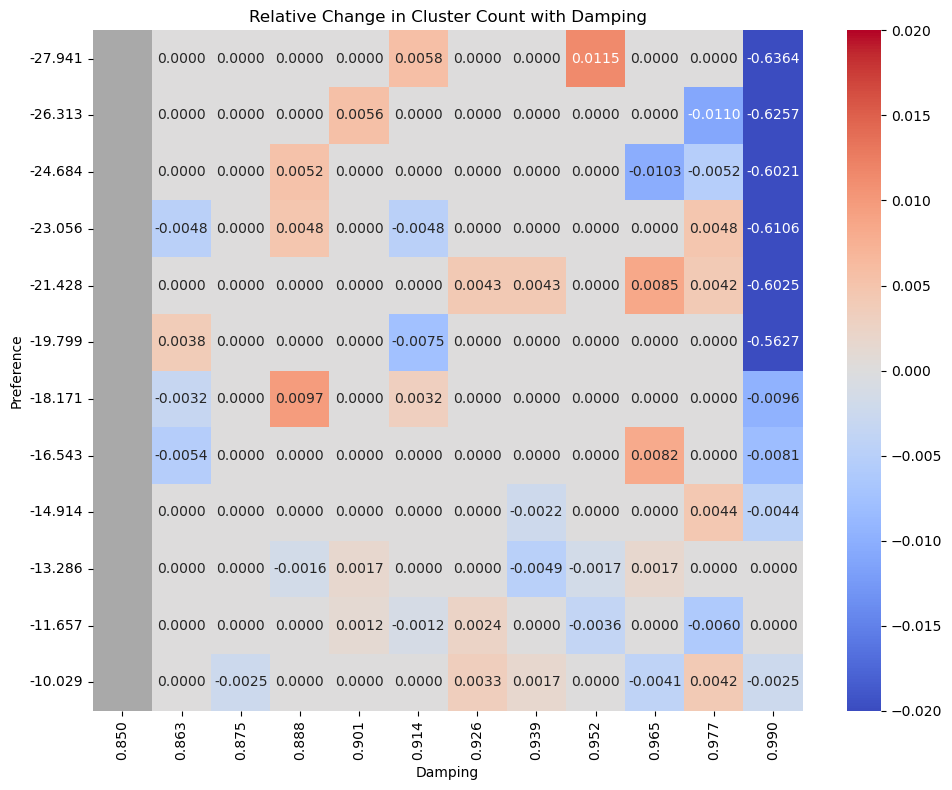

In [25]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    pivot_cluster_change_damp,
    annot=True,
    fmt=".4f",
    cmap=cmap,
    norm=mt.colors.TwoSlopeNorm(
        vmin=-0.02,
        vcenter=0,
        vmax=0.02
    )
)

plt.xticks(
    ticks=np.arange(len(pivot_cluster_change_damp.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_cluster_change_damp.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_cluster_change_damp.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_cluster_change_damp.index],
    rotation=0
)

plt.title("Relative Change in Cluster Count with Damping")
plt.xlabel("Damping")
plt.ylabel("Preference")

plt.tight_layout()
plt.show()
plt.close()

Here we see that relativly low change in `n_clusters` for for all values where `damping<0.99`

In [26]:
pivot_cluster_change_pref

damping,0.850000,0.862727,0.875455,0.888182,0.900909,0.913636,0.926364,0.939091,0.951818,0.964545,0.977273,0.990000
preference,,,,,,,,,,,,
-27.941062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-26.312706,0.040462,0.040462,0.040462,0.040462,0.046243,0.040230,0.040230,0.040230,0.028409,0.028409,0.017045,0.046875
-24.684350,0.072222,0.072222,0.072222,0.077778,0.071823,0.071823,0.071823,0.071823,0.071823,0.060773,0.067039,0.134328
-23.055993,0.077720,0.072539,0.072539,0.072165,0.072165,0.067010,0.067010,0.067010,0.067010,0.078125,0.089005,0.065789
-21.427637,0.125000,0.130435,0.130435,0.125000,0.125000,0.130435,0.135266,0.140097,0.140097,0.149758,0.149038,0.172840
-19.799280,0.128205,0.132479,0.132479,0.132479,0.132479,0.123932,0.119149,0.114407,0.114407,0.105042,0.100418,0.210526
-18.170924,0.170455,0.162264,0.162264,0.173585,0.173585,0.186312,0.186312,0.186312,0.186312,0.186312,0.186312,1.686957
-16.542568,0.190939,0.188312,0.188312,0.176849,0.176849,0.173077,0.173077,0.173077,0.173077,0.182692,0.182692,0.184466
-14.914211,0.236413,0.243169,0.243169,0.243169,0.243169,0.243169,0.243169,0.240437,0.240437,0.230352,0.235772,0.240437


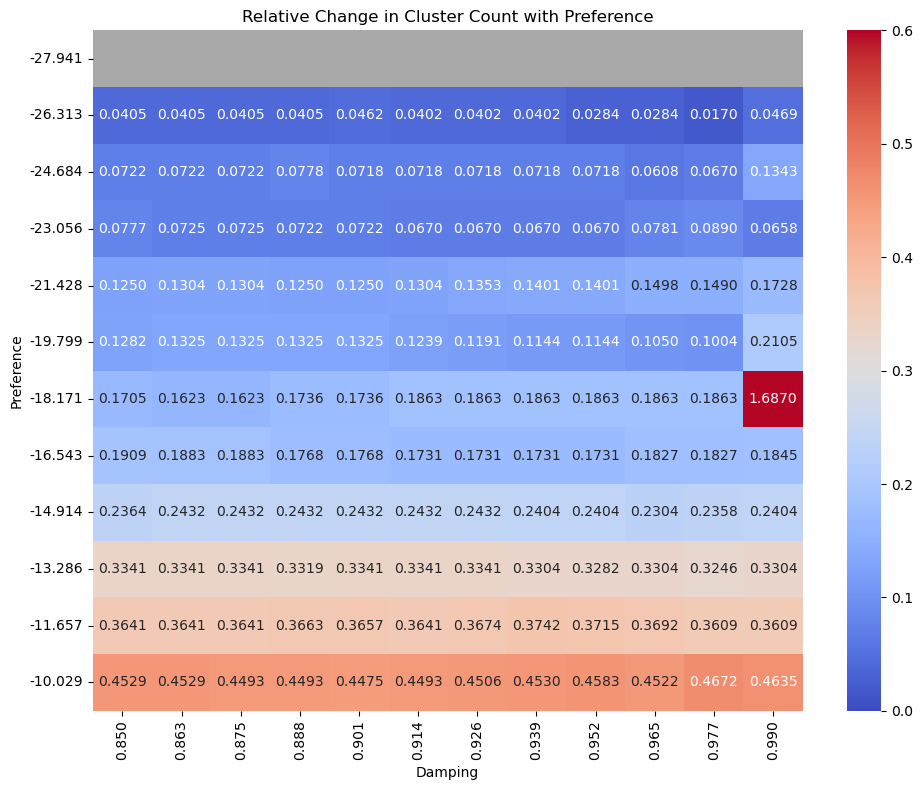

In [27]:
plt.figure(figsize=(10, 8))

norm = mt.colors.Normalize(
    vmin=0,
    vmax=0.6
)

sns.heatmap(
    pivot_cluster_change_pref,
    annot=True,
    fmt=".4f",
    cmap=cmap,
    norm=norm
)

plt.xticks(
    ticks=np.arange(len(pivot_cluster_change_pref.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_cluster_change_pref.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_cluster_change_pref.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_cluster_change_pref.index],
    rotation=0
)

plt.title("Relative Change in Cluster Count with Preference")
plt.xlabel("Damping")
plt.ylabel("Preference")

plt.tight_layout()
plt.show()
plt.close()

### Cluster-size behavior

Now lets look slightly more at the behavior of the fraction of singleton clusters, fraction of singleton clusters, and median cluster size. 

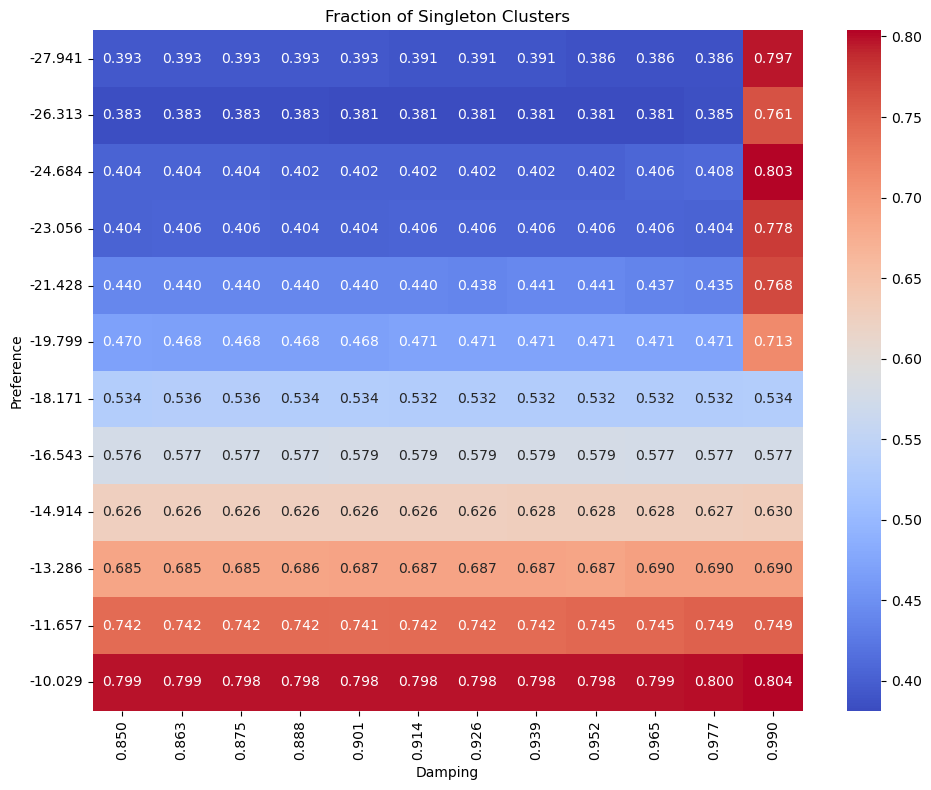

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_frac_singleton_clusters,
    annot=True,
    fmt="0.3f",
    cmap=cmap
)

plt.xticks(
    ticks=np.arange(len(pivot_frac_singleton_clusters.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_frac_singleton_clusters.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_frac_singleton_clusters.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_frac_singleton_clusters.index],
    rotation=0
)

plt.title('Fraction of Singleton Clusters')
plt.xlabel('Damping')
plt.ylabel('Preference')
plt.tight_layout()

plt.show()
plt.close()

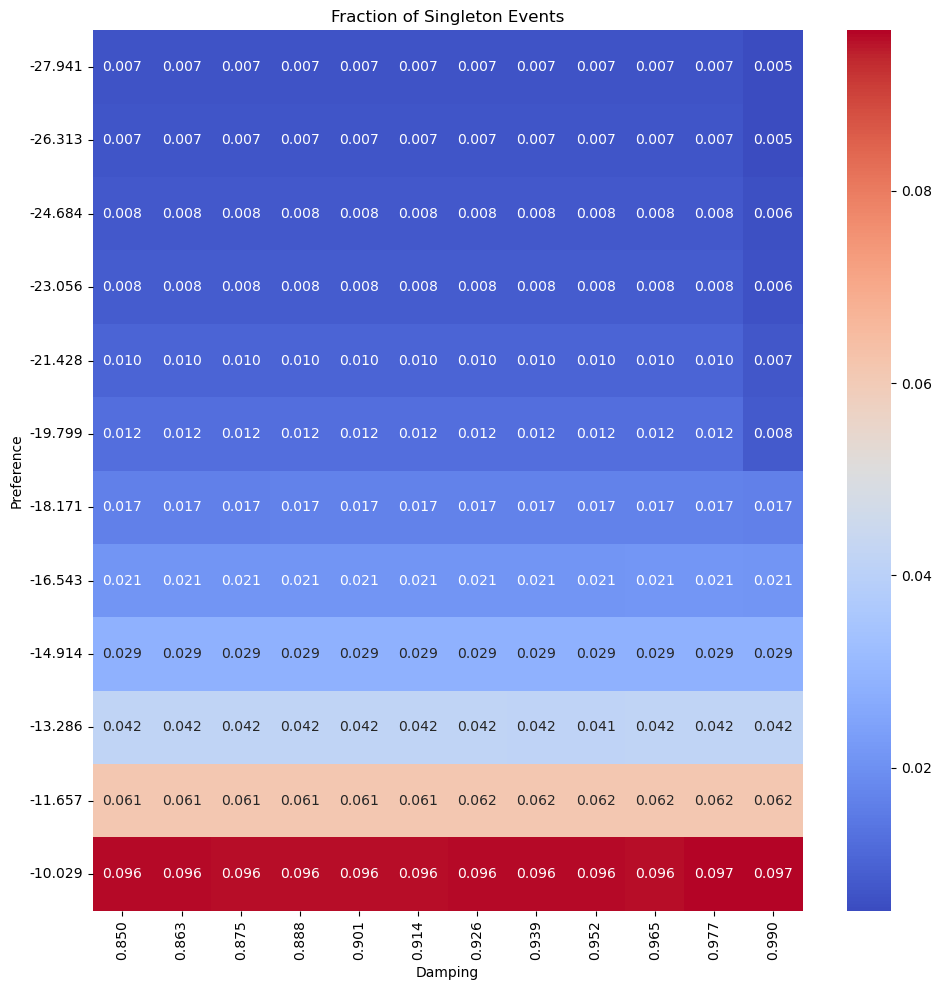

In [29]:
plt.figure(figsize=(10,10))

sns.heatmap(
    pivot_frac_singleton_events,
    annot=True,
    fmt="0.3f",
    cmap=color_scale
)

plt.xticks(
    ticks=np.arange(len(pivot_frac_singleton_events.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_frac_singleton_events.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_frac_singleton_events.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_frac_singleton_events.index],
    rotation=0
)

plt.title('Fraction of Singleton Events')
plt.xlabel('Damping')
plt.ylabel('Preference')
plt.tight_layout()

plt.show()
plt.close()

In general, we want to look for a model with a high median cluster size. This parameter space is between `pref: [-28, -19.8]` and `damp: [0.85, 0.99]`. Both could have a lower minimum. The maximum should be somewhat correct.

### Canidate Param Points

In [30]:
candidates = df[
    (df["damping"] < 0.98) &
    (df["preference"] <= -20) &
    (df["preference"] >= -28)
].copy()

In [31]:
candidates.describe()

,preference,damping,seed,n_clusters,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size,cluster_change_pref,cluster_change_damping
count,55.000000,55.000000,55.0,55.000000,55.000000,55.000000,55.000000,55.000000,55.0,55.000000,55.000000,55.000000,44.000000,50.000000
mean,-24.684350,0.913636,23.0,198.090909,130.290909,80.472727,0.404202,0.008047,1.0,709.254545,51.066593,7.600000,0.078793,0.000454
std,2.324069,0.040618,0.0,22.040596,49.997657,13.002642,0.019749,0.001300,0.0,93.115066,5.374264,1.024695,0.036419,0.003745
min,-27.941062,0.850000,23.0,173.000000,63.000000,68.000000,0.381215,0.006800,1.0,626.000000,41.841004,5.500000,0.017045,-0.011050
25%,-26.312706,0.875455,23.0,180.000000,87.500000,69.000000,0.388584,0.006900,1.0,639.000000,48.076923,7.000000,0.057141,0.000000
50%,-24.684350,0.913636,23.0,194.000000,120.000000,78.000000,0.402062,0.007800,1.0,640.000000,51.546392,8.000000,0.071994,0.000000
75%,-23.055993,0.951818,23.0,208.000000,168.000000,84.000000,0.405797,0.008400,1.0,765.500000,55.555556,8.000000,0.098004,0.000000
max,-21.427637,0.977273,23.0,239.000000,240.000000,104.000000,0.440678,0.010400,1.0,866.000000,57.803468,9.000000,0.149758,0.011494


In [32]:
frac_singleton_events_range = candidates['fraction_singleton_events'].max() - candidates['fraction_singleton_events'].min()
n_clusters_range = candidates['n_clusters'].max() - candidates['n_clusters'].min()
median_cluster_size_range = candidates['median_cluster_size'].max() - candidates['median_cluster_size'].min()

In [33]:
print(f'Range of fraction_singleton_events: {frac_singleton_events_range}')
print(f'Range of n_clusters: {n_clusters_range}')
print(f'Range of median_cluster_size: {median_cluster_size_range}')

Range of fraction_singleton_events: 0.0036
Range of n_clusters: 66
Range of median_cluster_size: 3.5


### Canidate Score

Here we will impliment a "canidate score" to see which parameters perform better than others. We reward: 

* low `fraction_singleton_events` (range 0.0036: [0.0068, 0.0104]: [0.68%, 1.04%])
* low `n_clusters` (range 66: [173, 239])
* high `median_cluster_size` (range 3.5: [5.5, 9])

A lower score indicates a better performing canidate.

In [34]:
o_frac_single_events = 0.8e-2
o_n_clusters = 2e2
o_med_cluster_size = 7.6e1

In [35]:
candidates = df[
    (df["damping"] < 0.98) &
    (df["preference"] <= -20) &
    (df["preference"] >= -28)
].copy()

In [36]:
candidates["score"] = (
    100 * candidates["fraction_singleton_events"] +
    0.01 * candidates["n_clusters"] +
    0.1 * candidates['median_cluster_size']
)

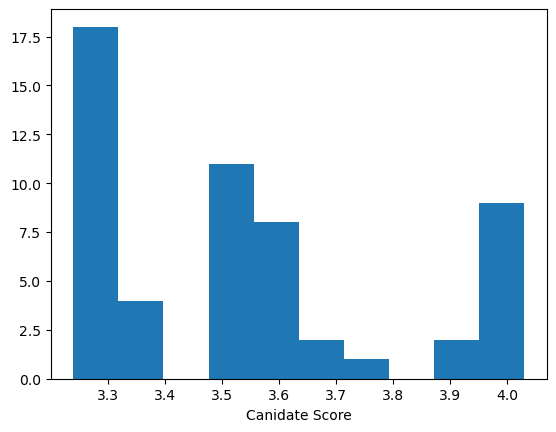

In [37]:
plt.hist(candidates['score'])
plt.xlabel('Canidate Score')
plt.show()
plt.close()

In [38]:
pivot_canidates = candidates.pivot(
    index="preference",
    columns="damping",
    values="score"
)

In [39]:
pivot_canidates

damping,0.850000,0.862727,0.875455,0.888182,0.900909,0.913636,0.926364,0.939091,0.951818,0.964545,0.977273
preference,,,,,,,,,,,
-27.941062,3.31,3.31,3.31,3.31,3.31,3.32,3.32,3.32,3.24,3.24,3.34
-26.312706,3.29,3.29,3.29,3.29,3.30,3.30,3.30,3.30,3.30,3.30,3.28
-24.684350,3.51,3.51,3.51,3.52,3.52,3.52,3.52,3.52,3.52,3.50,3.49
-23.055993,3.72,3.71,3.71,3.62,3.62,3.61,3.61,3.61,3.61,3.61,3.62
-21.427637,3.97,3.97,3.97,3.97,3.97,3.97,3.98,3.95,3.95,4.02,4.03


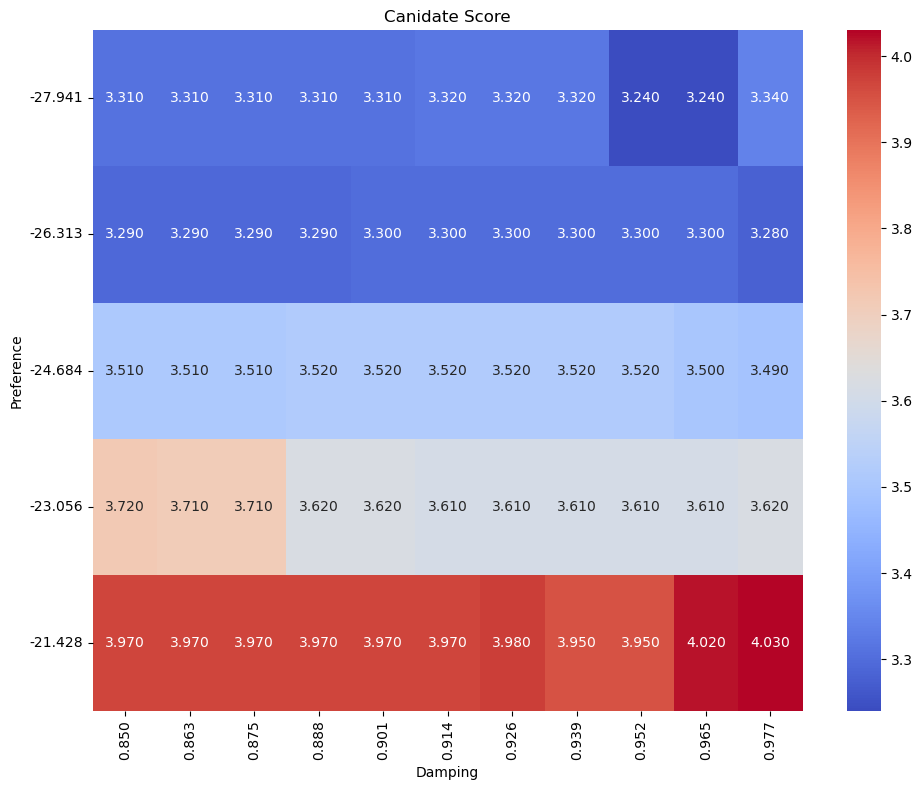

In [40]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_canidates,
    annot=True,
    fmt=".3f",
    cmap=cmap
)

plt.xticks(
    ticks=np.arange(len(pivot_canidates.columns)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_canidates.columns]
)

plt.yticks(
    ticks=np.arange(len(pivot_canidates.index)) + 0.5,
    labels=[f"{x:.3f}" for x in pivot_canidates.index],
    rotation=0
)

plt.title('Canidate Score')
plt.xlabel('Damping')
plt.ylabel('Preference')
plt.tight_layout()

plt.show()
plt.close()

## Additional Cluster Analysis

We can see that `pref` values [-26,-28] is likely the ROI here. The `damp` value for [0.86, 0.98] does not have a signifigant impact on this.

Different way to visualize the heat map:

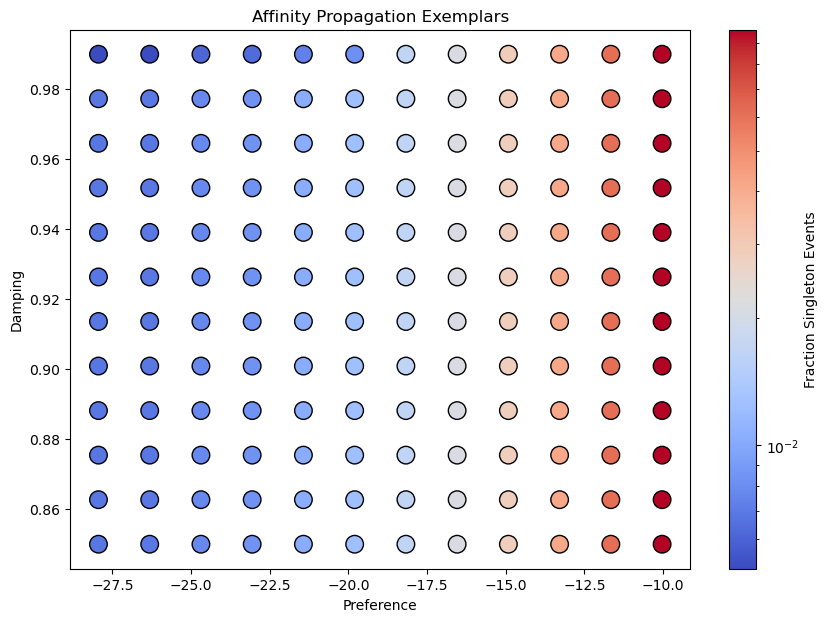

In [41]:
plt.figure(figsize=(10, 7))

sc = plt.scatter(
    ap_param_grid['preference'],
    ap_param_grid['damping'],
    c=ap_param_grid['fraction_singleton_events'],
    cmap=cmap,
    norm=mt.colors.LogNorm(),
    s=160,
    edgecolors='black'
)

plt.colorbar(sc, label='Fraction Singleton Events')

ax = plt.gca()

plt.xlabel('Preference')
plt.ylabel('Damping')
plt.title('Affinity Propagation Exemplars')

#plt.savefig('../outputs/figs/ap_param_sweep.png')
#plt.savefig('../outputs/figs/ap_param_sweep.svg', format='svg', dpi=1200)

plt.show()
plt.close()

***I need to rerun the AP param sweep with `pref`: [min(S), -26] and `damp`: [0.70,0.98]***

# AP Stability Test

I ran `apStabilitySweep.py` locally on my Macbook Pro M2 Pro with 10 cores and 16 GB ram. I ran it with 3 jobs and 5 seeds on the following parameter space: 

`pref: -26.313 -26.856 -27.398 -27.941`

`dampings: 0.85 0.875 0.901 0.926 0.952 0.965`

Below is the terminal output:

(base) MacBook-Pro-13:scripts calvinhinkle$ /usr/bin/time -p python apStabilitySweep.py --pulse_file '../data/day16_chan03_10000_20260803.npy' --save_directory '../data/' --n_jobs 3 --prefs -26.313 -26.856 -27.398 -27.941 --dampings 0.85 0.875 0.901 0.926 0.952 0.965
Number of tasks: 120
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   2 tasks      | elapsed:  1.7min
[Parallel(n_jobs=3)]: Done   7 tasks      | elapsed:  3.8min
[Parallel(n_jobs=3)]: Done  12 tasks      | elapsed:  6.1min
[Parallel(n_jobs=3)]: Done  19 tasks      | elapsed:  8.7min
[Parallel(n_jobs=3)]: Done  26 tasks      | elapsed: 11.6min
[Parallel(n_jobs=3)]: Done  35 tasks      | elapsed: 15.5min
[Parallel(n_jobs=3)]: Done  44 tasks      | elapsed: 18.0min
[Parallel(n_jobs=3)]: Done  55 tasks      | elapsed: 22.3min
[Parallel(n_jobs=3)]: Done  66 tasks      | elapsed: 26.2min
[Parallel(n_jobs=3)]: Done  79 tasks      | elapsed: 34.9min
[Parallel(n_jobs=3)]: Done  92 tasks      | elapsed: 46.8min
[Parallel(n_jobs=3)]: Done 107 tasks      | elapsed: 69.3min
[Parallel(n_jobs=3)]: Done 120 out of 120 | elapsed: 77.5min finished
AP grid search saved at ../data/20260821_ap_stability_day16_chan03_10000_20260803_2.pkl
real 4667.36
user 10304.60
sys 1771.12


In [42]:
userTime = 10304.60 #s
sysTime = 1771.12 #s

In [43]:
print(f'user time: {userTime/60:.2f} min = {userTime/3600:.2f} hour')
print(f'sys time: {sysTime/60:.2f} min = {sysTime/3600:.2f} hour')
print(f'CPU time: {userTime+sysTime:.2f} sec = {(userTime+sysTime)/60:.2f} min = {(userTime+sysTime)/3600:.2f} hr')

user time: 171.74 min = 2.86 hour
sys time: 29.52 min = 0.49 hour
CPU time: 12075.72 sec = 201.26 min = 3.35 hr


The script completed in 1 hr 17 min 30 s of wall-clock time, consuming 3.35 CPU-hours (12,075.72 CPU seconds) with a peak memory usage of 3.60 GB RAM per job. 

Lets load the stability test:

In [44]:
ap_stability_grid = pd.read_pickle(f'../data/20260821_ap_stability_day16_chan03_10000_20260803_2.pkl')

In [45]:
ap_stability_grid.head()

,preference,damping,seed,labels,n_clusters,converged,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size
0,-26.313,0.85,254119,"[144, 85, 60, 59, 18, 47, 18, 67, 60, 67, 67, ...",180,True,104,69,0.383333,0.0069,1,708,55.555556,8.0
1,-26.313,0.85,918756,"[144, 85, 60, 59, 18, 47, 18, 67, 60, 67, 67, ...",180,True,101,69,0.383333,0.0069,1,708,55.555556,8.0
2,-26.313,0.85,250527,"[144, 85, 60, 59, 18, 47, 18, 67, 60, 67, 67, ...",180,True,104,69,0.383333,0.0069,1,708,55.555556,8.0
3,-26.313,0.85,576151,"[144, 85, 60, 59, 18, 47, 18, 67, 60, 67, 67, ...",180,True,106,69,0.383333,0.0069,1,708,55.555556,8.0
4,-26.313,0.85,713992,"[144, 85, 60, 59, 18, 47, 18, 67, 60, 67, 67, ...",180,True,108,69,0.383333,0.0069,1,708,55.555556,8.0


In [46]:
ap_stability_grid.describe()

,preference,damping,seed,n_clusters,n_iter,n_singleton_clusters,fraction_singleton_clusters,fraction_singleton_events,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.00000,120.0,120.000000,120.000000,120.000000
mean,-27.127000,0.911500,542709.000000,177.950000,109.758333,68.500000,0.385002,0.00685,1.0,787.166667,56.210189,8.308333
std,0.609189,0.040868,262062.442576,2.872208,37.700722,0.502096,0.004236,0.00005,0.0,79.164581,0.914003,0.440508
min,-27.941000,0.850000,250527.000000,173.000000,60.000000,68.000000,0.381215,0.00680,1.0,708.000000,55.248619,8.000000
25%,-27.533750,0.875000,254119.000000,175.750000,82.250000,68.000000,0.381215,0.00680,1.0,708.000000,55.248619,8.000000
50%,-27.127000,0.913500,576151.000000,178.000000,110.500000,68.500000,0.382678,0.00685,1.0,787.500000,56.179775,8.000000
75%,-26.720250,0.952000,713992.000000,181.000000,127.000000,69.000000,0.387873,0.00690,1.0,866.000000,56.899351,9.000000
max,-26.313000,0.965000,918756.000000,181.000000,203.000000,69.000000,0.393064,0.00690,1.0,866.000000,57.803468,9.000000


In [47]:
print(f'Size of stablity df: {ap_stability_grid.memory_usage().sum() * 1e-3:.2f} kb')

Size of stablity df: 12.73 kb


## Analysis

In [ ]:
from itertools import combinations
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import numpy as np

ari_results = []

# Each parameter combination
for (preference, damping), group in ap_stability.groupby(
    ["preference", "damping"]
):

    rows = list(group.iterrows())

    # Compare every pair of seeds
    for (idx_a, row_a), (idx_b, row_b) in combinations(rows, 2):

        ari = adjusted_rand_score(
            row_a["labels"],
            row_b["labels"]
        )

        ari_results.append({
            "preference": preference,
            "damping": damping,
            "seed_a": row_a["seed"],
            "seed_b": row_b["seed"],
            "ARI": ari
        })

ari_df = pd.DataFrame(ari_results)

print(ari_df)

In [ ]:
ari_summary = (
    ari_df
    .groupby(["preference", "damping"])["ARI"]
    .agg(
        mean_ARI="mean",
        median_ARI="median",
        std_ARI="std",
        min_ARI="min",
        max_ARI="max"
    )
    .reset_index()
)

print(
    ari_summary.sort_values(
        "mean_ARI",
        ascending=False
    ).to_string(index=False)
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

preference = -26.313
damping = 0.85

group = ap_stability[
    (ap_stability["preference"] == preference) &
    (ap_stability["damping"] == damping)
]

seeds = group["seed"].tolist()

ari_matrix = np.zeros((len(seeds), len(seeds)))

for i, seed_a in enumerate(seeds):
    labels_a = group[group["seed"] == seed_a]["labels"].iloc[0]

    for j, seed_b in enumerate(seeds):
        labels_b = group[group["seed"] == seed_b]["labels"].iloc[0]

        ari_matrix[i, j] = adjusted_rand_score(
            labels_a,
            labels_b
        )

plt.figure(figsize=(7, 6))

sns.heatmap(
    ari_matrix,
    xticklabels=seeds,
    yticklabels=seeds,
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.xlabel("Seed")
plt.ylabel("Seed")
plt.title(
    f"AP Seed Stability\n"
    f"preference={preference}, damping={damping}"
)

plt.tight_layout()
plt.show()

In [ ]:
pivot_ari = ari_summary.pivot(
    index="preference",
    columns="damping",
    values="mean_ARI"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_ari,
    annot=True,
    fmt=".4f",
    vmin=0,
    vmax=1,
    cmap="viridis"
)

plt.xlabel("Damping")
plt.ylabel("Preference")
plt.title("AP Stability Across Random Seeds\nMean Pairwise ARI")

plt.tight_layout()
plt.show()

In [ ]:
pivot_min_ari = ari_summary.pivot(
    index="preference",
    columns="damping",
    values="min_ARI"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_min_ari,
    annot=True,
    fmt=".4f",
    vmin=0,
    vmax=1,
    cmap="viridis"
)

plt.xlabel("Damping")
plt.ylabel("Preference")
plt.title("AP Stability Across Random Seeds\nMinimum Pairwise ARI")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import adjusted_rand_score

# Use only parameter combinations that actually exist
params = (
    ap_stability[
        ["preference", "damping"]
    ]
    .drop_duplicates()
    .values
)

parameter_ari = []

for preference, damping in params:

    # Find neighboring points in preference
    for other_preference, other_damping in params:

        # Same damping, neighboring preference
        same_damping = np.isclose(damping, other_damping)

        # Same preference, neighboring damping
        same_preference = np.isclose(preference, other_preference)

        if same_damping and preference != other_preference:
            pass
        elif same_preference and damping != other_damping:
            pass
        else:
            continue

        # Only compare each pair once
        if (preference, damping) >= (
            other_preference,
            other_damping
        ):
            continue

        # Compare using the same seed
        common_seeds = set(
            ap_stability[
                (ap_stability.preference == preference) &
                (ap_stability.damping == damping)
            ]["seed"]
        ) & set(
            ap_stability[
                (ap_stability.preference == other_preference) &
                (ap_stability.damping == other_damping)
            ]["seed"]
        )

        for seed in common_seeds:

            labels_a = ap_stability[
                (ap_stability.preference == preference) &
                (ap_stability.damping == damping) &
                (ap_stability.seed == seed)
            ]["labels"].iloc[0]

            labels_b = ap_stability[
                (ap_stability.preference == other_preference) &
                (ap_stability.damping == other_damping) &
                (ap_stability.seed == seed)
            ]["labels"].iloc[0]

            ari = adjusted_rand_score(
                labels_a,
                labels_b
            )

            parameter_ari.append({
                "preference_a": preference,
                "damping_a": damping,
                "preference_b": other_preference,
                "damping_b": other_damping,
                "seed": seed,
                "ARI": ari
            })

parameter_ari_df = pd.DataFrame(parameter_ari)

print(parameter_ari_df)

In [ ]:
parameter_ari_summary = (
    parameter_ari_df
    .groupby([
        "preference_a",
        "damping_a",
        "preference_b",
        "damping_b"
    ])["ARI"]
    .agg(
        mean_ARI="mean",
        min_ARI="min",
        std_ARI="std"
    )
    .reset_index()
)

print(parameter_ari_summary)

seed stability: ARI_{seed}
local param stabiltiy: ARI_{param}
then look at phyical 

# New AP notes

 * AP param serach
    * each (pref, damping) pair:
       * run AP 
       * record seed
       * record 
         * convergance  
         * n_iter
         * n_clusters
         * n_singleton_clusters
         * fraction_singleton_clusters
         * fraction_singleton_events
         * min_cluster_size
         * max_cluster_size
         * mean_cluster_size
         * median_cluster_size
    * save AP grid dataframe  
 * Stability analysis (probably in AP param search)
    * Select candidate pararmeter points based on stabilty, cluster size, etc
    * For each candidate run an AP model with $N$ seeds
    * compare the labels
    * calcaulte ARI 
      * mean ARI
      * median ARI 
      * min ARI
      * std ARI
* Physical validation (probably in AP param search)
  * for stable AP models
    * determine menaigful differences for 
      * `ig_laser`
      * `multiplicity`
      * `energy`
* Manual labeling
  * select AP model
  * inspect exemplars
  * map AP clusters to physcial categories ($\approx 5$)
* Train SVM using manually labeled data
* Validate on held-out data


 

For now I will run the cluster sizess and singletons. I can adapt this to run with 5 seeds later but this will obviously increase the CPU time by 5x. First find promising params, then compare stabilty. Prorbaly make a new script for stability analysis